In [ ]:
%load_ext autoreload
%autoreload 2

# for src folder access
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import os
from matplotlib import pyplot as plt

from src.config import Config, DEFAULT_DATA_ROOT, TRIMMED_DATA_ROOT, default_session_to_activity
from src.preprocessing.clap_sync import accel_magnitude
from src.preprocessing.io_ax6 import find_session_file, load_ax6_csv

DEFAULT_DATA_ROOT

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


WindowsPath('C:/Users/blue_/Desktop/git-repos/HAR_Projekt/ax6_cnn_project/data/raw')

### Load data

In [29]:
sessions_to_activities = default_session_to_activity()
existing_trims = [int(filename[:2]) for filename in os.listdir(TRIMMED_DATA_ROOT)]

data_paths = {s: [
    find_session_file(DEFAULT_DATA_ROOT, Config.left_id, s), 
    find_session_file(DEFAULT_DATA_ROOT, Config.right_id, s)
] for s in range(12, 12 + len(sessions_to_activities.keys())) if s not in existing_trims}

dfs = {s: [
    load_ax6_csv(left),
    load_ax6_csv(right)
] for s, (left, right) in data_paths.items()}

print("Missing sessions: ", dfs.keys())
list(dfs.values())[0][0]

Missing sessions:  dict_keys([22, 23, 24, 25, 26, 27, 28, 29, 30, 31])


,ax,ay,az,gx,gy,gz
0,-0.452148,-0.904785,-0.011230,5.653381,17.089844,-0.450134
1,-0.447266,-0.905273,-0.012695,5.996704,17.997742,0.144958
2,-0.442139,-0.910156,-0.014160,6.324768,18.508911,0.495911
3,-0.441406,-0.918213,-0.014404,6.805419,18.791199,0.900268
4,-0.437744,-0.922852,-0.015137,7.095336,18.951416,1.358032
...,...,...,...,...,...,...
27995,0.585205,0.919189,0.147949,-61.042782,14.602660,14.717101
27996,0.570313,0.852051,0.153320,-61.828609,10.818480,21.812437
27997,0.539795,0.817871,-0.013428,-73.051453,24.986265,27.473448
27998,0.476563,0.860107,0.118164,-57.060238,29.846189,30.921934


### Calculate acceloration magnitude

In [31]:
for _, (dfL, dfR) in dfs.items():
    dfL["acc_mag"] = accel_magnitude(dfL)
    dfR["acc_mag"] = accel_magnitude(dfR)

In [20]:
# interactive plot
%matplotlib widget

from typing import Tuple
import pandas as pd


class InteractiveCutter:
    def __init__(self, dfL, dfR, exercise_id, figsize=(15, 3)):
        """Interactive plot using pyplot for manually removing excess data 

        Args:
            dfL (pandas.DataFrame): DataFrame from left sensor
            dfR (pandas.DataFrame): DataFrame from right sensor
            exercise_id (str): Plot label (just decorative)
            figsize (tuple, optional): (width, height). Defaults to (15, 3).
        """
        self.active_line = None  # currently picked lines
        self.dfL = dfL
        self.dfR = dfR
        
        self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=figsize)
        
        # plot
        self.dfL["acc_mag"].plot(ax=self.ax1, label="Left Sensor")
        self.dfR["acc_mag"].plot(ax=self.ax2, label="Right Sensor")
        
        # calc initial vlines indices
        idx_min = self.dfL.index.min()
        idx_max = self.dfL.index.max()
        width = (idx_max - idx_min) * 0.2
        p1, p2 = idx_min + 100, idx_min + 100 + width  # same for dfL and dfR
        
        self.lines = [
            self.ax1.axvline(p1, color='red', linestyle='--', lw=3, picker=5),
            self.ax1.axvline(p2, color='red', linestyle='--', lw=3, picker=5),
            self.ax2.axvline(p1, color='red', linestyle='--', lw=3, picker=5),
            self.ax2.axvline(p2, color='red', linestyle='--', lw=3, picker=5)
        ]
        
        # link callback methods
        self.fig.canvas.mpl_connect('pick_event', self._on_pick)
        self.fig.canvas.mpl_connect('motion_notify_event', self._on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self._on_release)
        
        self.ax1.title.set_text(str(exercise_id))
        plt.tight_layout()
        plt.show()

    def _on_pick(self, event):
        if event.artist in self.lines:
            self.active_line = event.artist

    def _on_release(self, event):
        self.active_line = None

    def _on_motion(self, event):
        if self.active_line and event.xdata is not None:
            # get current positions
            l1, r1 = self.lines[0].get_xdata()[0], self.lines[1].get_xdata()[0]
            l2, r2 = self.lines[2].get_xdata()[0], self.lines[3].get_xdata()[0]
            
            # moved lines in first plot
            if self.active_line in self.lines[:2]:
                self.active_line.set_xdata([event.xdata, event.xdata])
                
                # calc distance of lines in first plot to ...
                new_width = abs(self.lines[1].get_xdata()[0] - self.lines[0].get_xdata()[0])
                
                # ... force same width in second plot
                self.lines[3].set_xdata([l2 + new_width, l2 + new_width])
            
            # moved lines in second plot
            elif self.active_line in self.lines[2:]:
                width_top = abs(r1 - l1)
                if self.active_line == self.lines[2]:   # left line picked -> move right line to keep same width
                    self.lines[2].set_xdata([event.xdata, event.xdata])
                    self.lines[3].set_xdata([event.xdata + width_top, event.xdata + width_top])
                else:                                   # right line picked -> move left line too
                    self.lines[3].set_xdata([event.xdata, event.xdata])
                    self.lines[2].set_xdata([event.xdata - width_top, event.xdata - width_top])
            
            self.fig.canvas.draw_idle()

    def get_data(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """Extracts data between set lines and create new DataFrames

        Returns:
            Tuple[pd.DataFrame, pd.DataFrame]: dfL_cut, dfR_cut
        """
        lim_L = sorted([self.lines[0].get_xdata()[0], self.lines[1].get_xdata()[0]])
        lim_R = sorted([self.lines[2].get_xdata()[0], self.lines[3].get_xdata()[0]])
        
        df_cut_L = self.dfL.loc[(self.dfL.index >= lim_L[0]) & (self.dfL.index <= lim_L[1])].copy()
        df_cut_R = self.dfR.loc[(self.dfR.index >= lim_R[0]) & (self.dfR.index <= lim_R[1])].copy()
        
        return df_cut_L, df_cut_R

### Trim manually

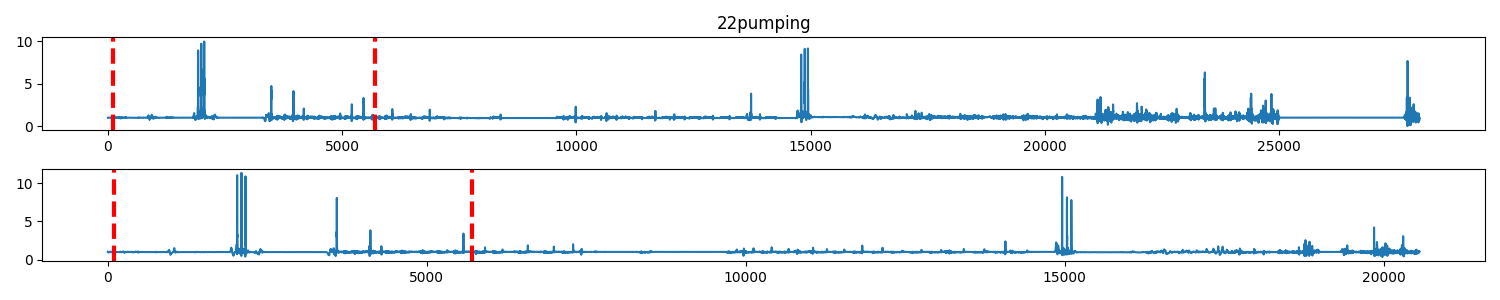

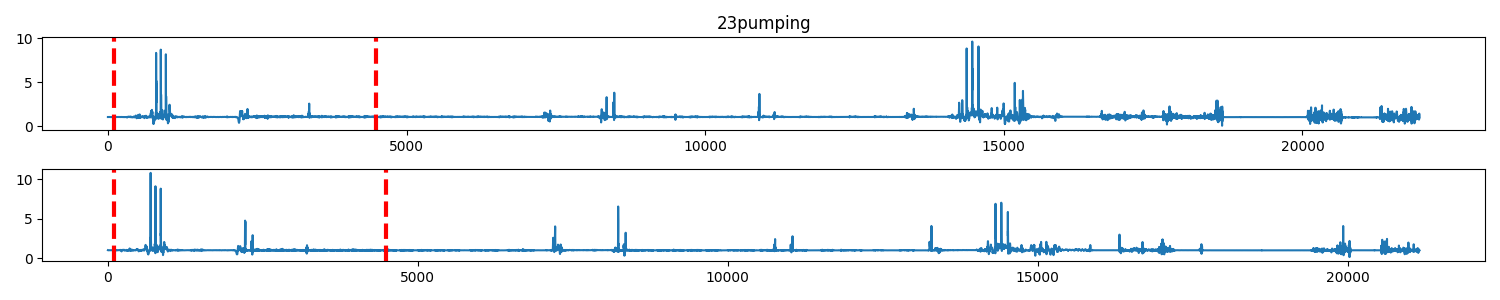

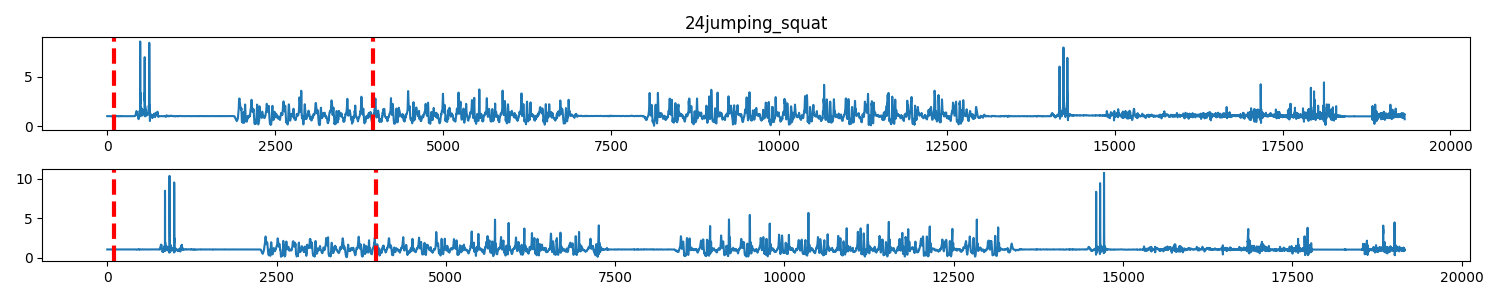

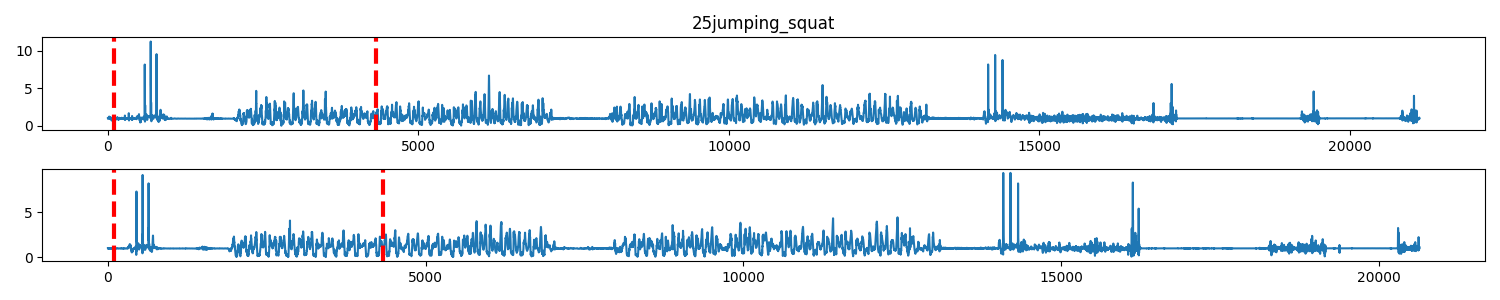

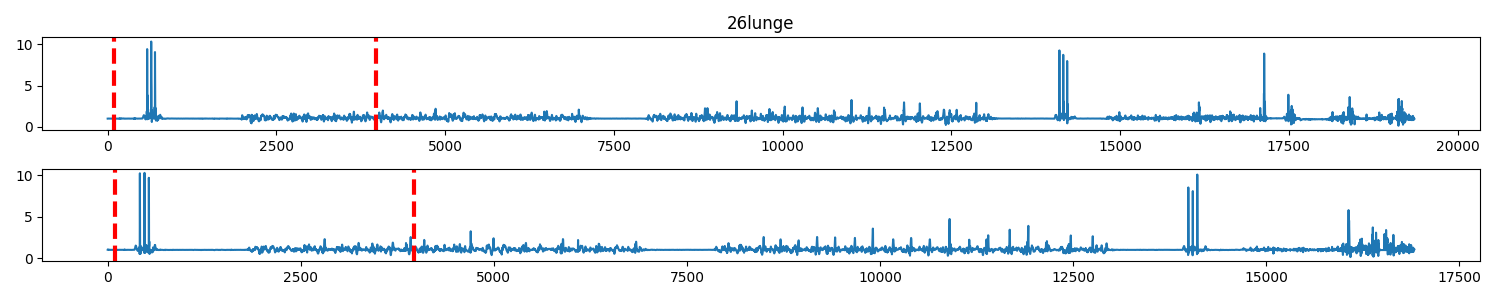

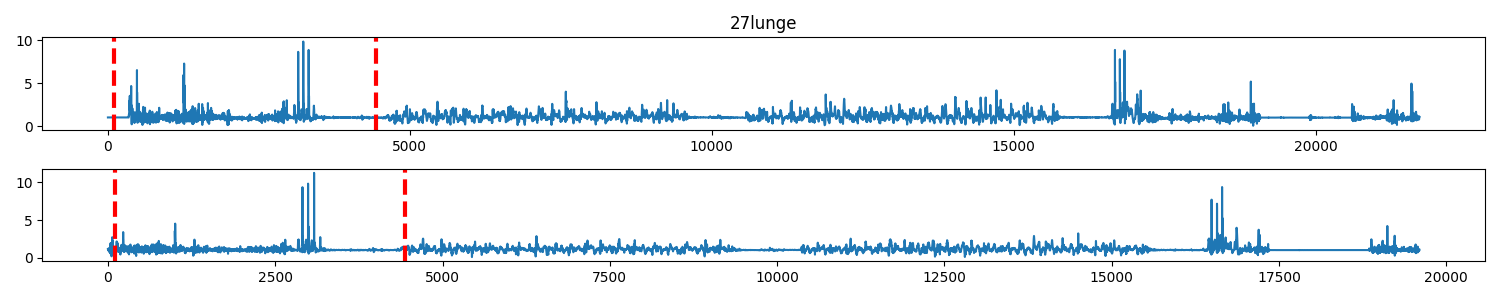

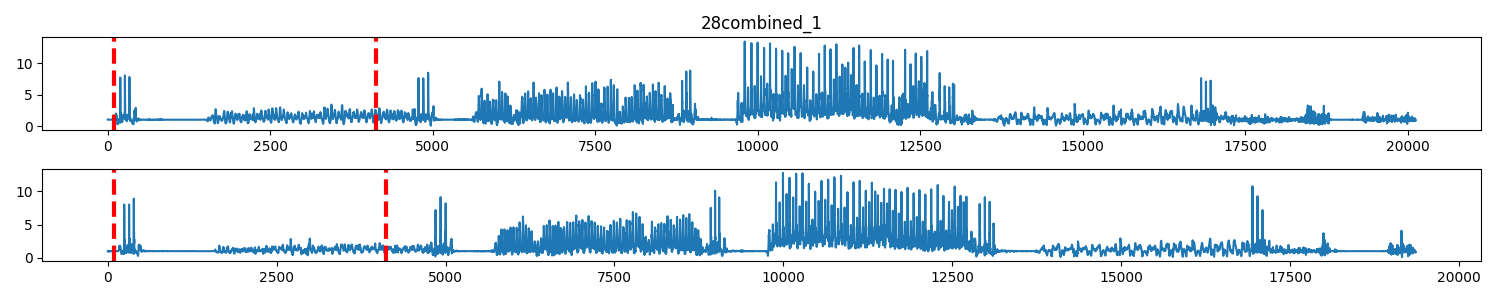

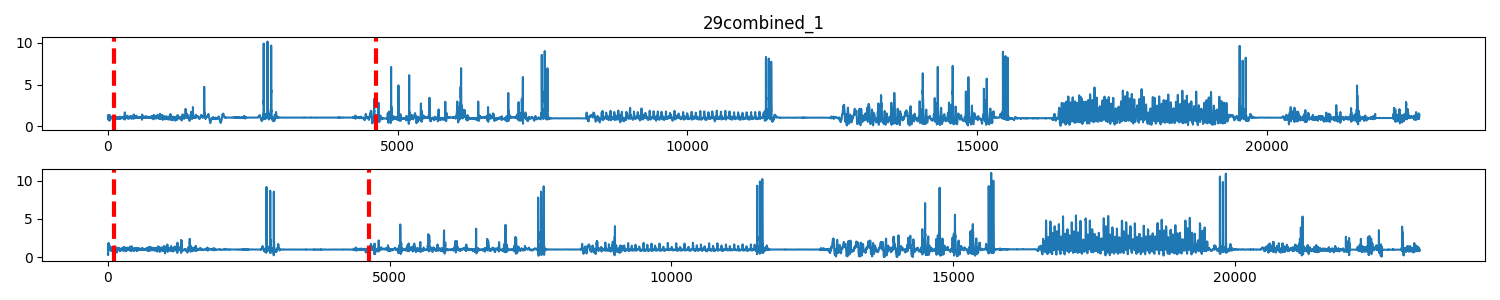

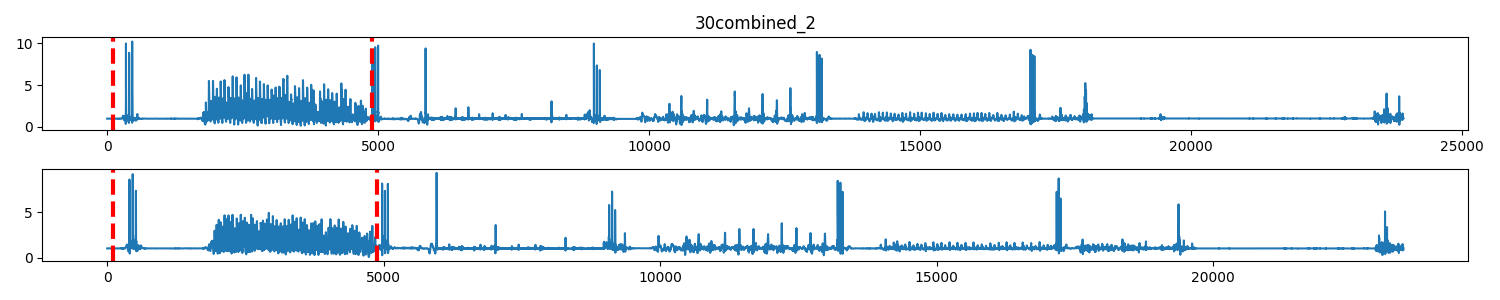

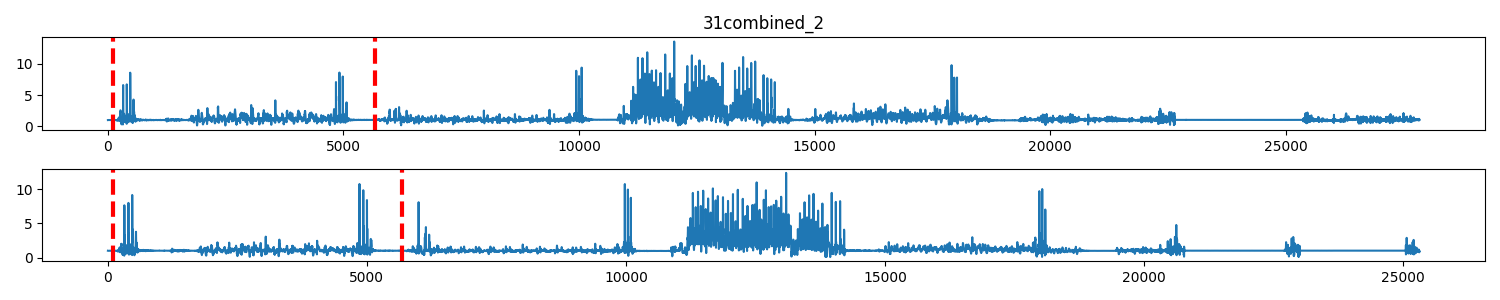

In [32]:
cutters = [InteractiveCutter(dfL, dfR, str(id)+default_session_to_activity()[str(id)]) for id, (dfL, dfR) in (dfs.items())]

### Result example (interactive plots wont be saved when juypter server restarts)

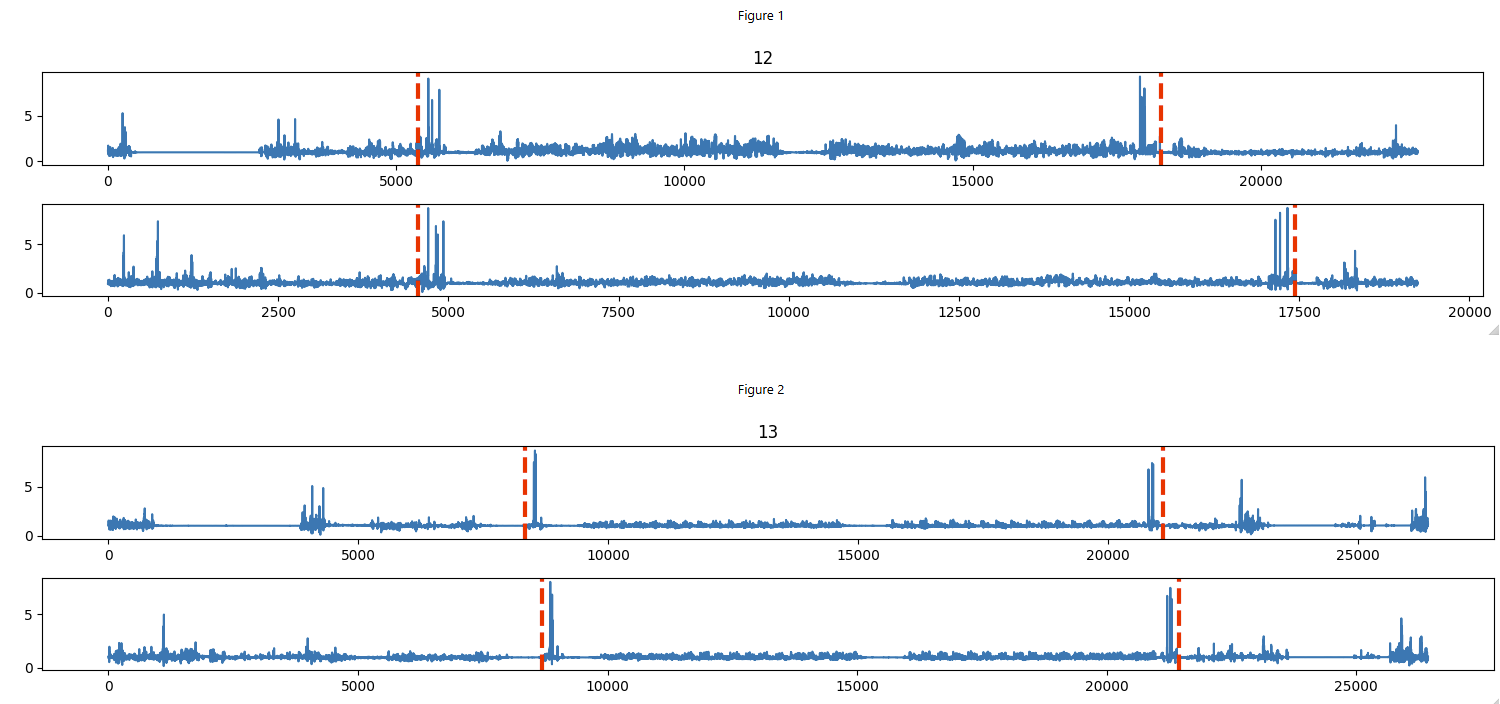

In [10]:
from IPython.display import Image
Image(filename="example_trim.png")

### Show first 6 seconds (later used for synchronisation)

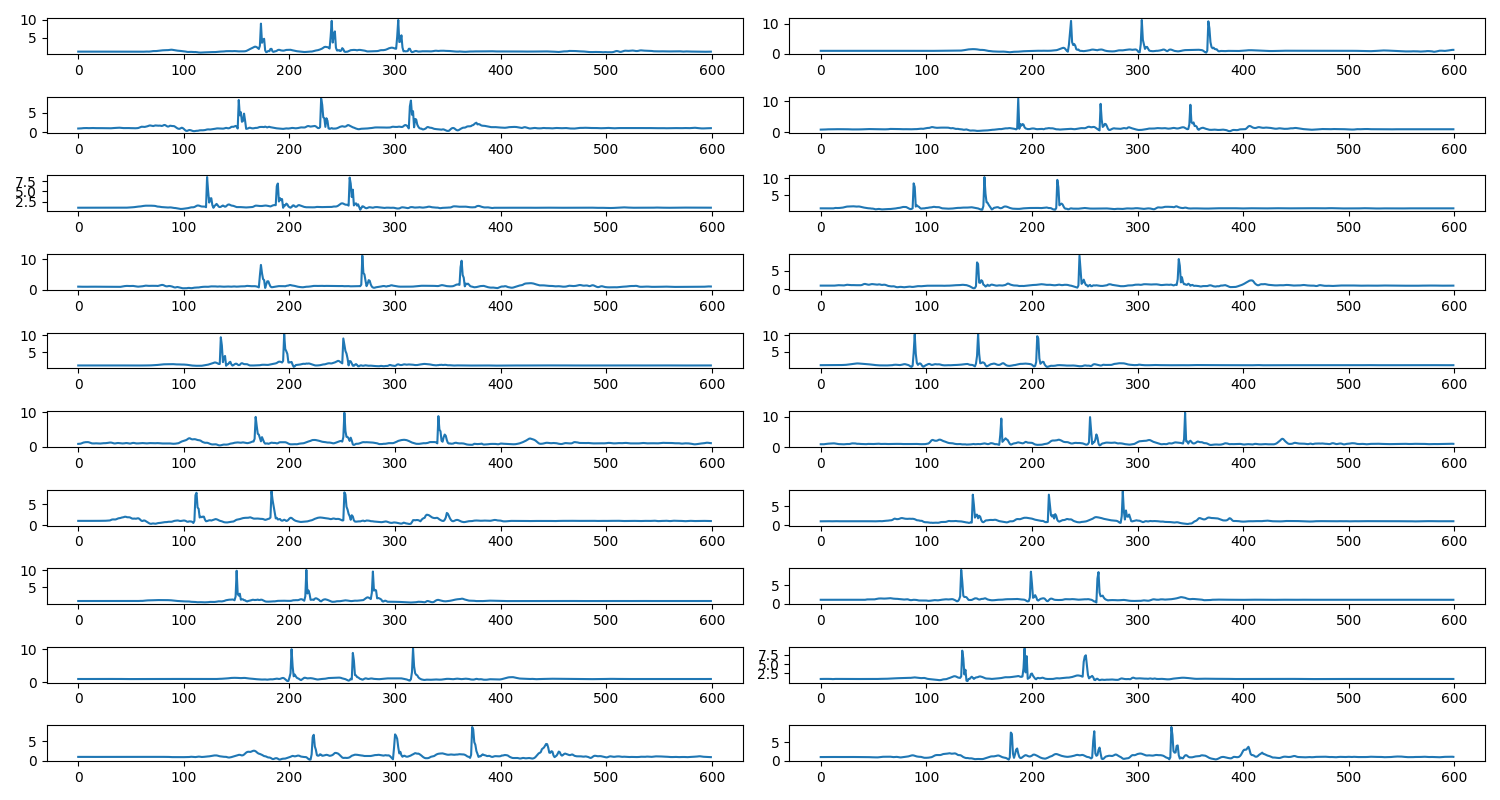

In [36]:
trimmed_dfs = {id: c.get_data() for id, c in zip(dfs.keys(), cutters)}

fig, ax = plt.subplots(10, 2, figsize=(15, 8))
for (ax1, ax2), (dfL, dfR) in zip(ax, trimmed_dfs.values()):
    ax1.plot(accel_magnitude(dfL)[:600])
    ax2.plot(accel_magnitude(dfR)[:600])
plt.tight_layout()

### Save the files

In [37]:
if not os.path.exists(TRIMMED_DATA_ROOT):
    os.mkdir(TRIMMED_DATA_ROOT)
    
for id, (dfL, dfR) in trimmed_dfs.items():
    _path = os.path.join(TRIMMED_DATA_ROOT, str(id))
    if _path + "left.csv" not in os.listdir(TRIMMED_DATA_ROOT):
        dfL.to_csv(_path + "left.csv", index=False)
        dfR.to_csv(_path + "right.csv", index=False)